In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from itertools import combinations
from scipy.stats import chisquare, entropy, ks_2samp, wasserstein_distance
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import umap.umap_ as umap


In [ ]:
real_path = "../../data/real.csv"
syn_path = "../../data/synthetic.csv"
df_real = pd.read_csv(real_path)
df_syn = pd.read_csv(syn_path)

# Structural Consistency

## Structural Consistency Score
compares the structural characteristics of an original and synthetic dataset and returns a universal similarity score between 0 and 1, where 1 indicates high structural similarity.

In [33]:
def compute_structural_similarity_score(original: pd.DataFrame,
                                        synthetic: pd.DataFrame,
                                        eps=0.5,
                                        min_samples=5,
                                        weights=None):
    """
    Computes a universal structural similarity score ∈ [0,1], where 1 is best.
    Integrates:
      - Cluster Purity (KMeans & DBSCAN)
      - Adjusted Rand Index (KMeans & DBSCAN)
      - Cosine Similarity of global mean feature vectors
    Each subscore ∈ [0,1]; final score is the average.
    """
    # Preprocessing: one-hot encode categorical + standardize numeric
    num_cols = original.select_dtypes(include=[np.number]).columns.intersection(
               synthetic.select_dtypes(include=[np.number]).columns)
    cat_cols = original.select_dtypes(exclude=[np.number]).columns.intersection(
               synthetic.select_dtypes(exclude=[np.number]).columns)
    
    if len(cat_cols) > 0:
        combined_cat = pd.concat([original[cat_cols], synthetic[cat_cols]], axis=0)
        encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        encoder.fit(combined_cat)
        orig_cat = encoder.transform(original[cat_cols])
        syn_cat = encoder.transform(synthetic[cat_cols])
    else:
        orig_cat = np.empty((len(original), 0))
        syn_cat = np.empty((len(synthetic), 0))
    
    orig_num = original[num_cols].to_numpy()
    syn_num  = synthetic[num_cols].to_numpy()
    scaler = StandardScaler().fit(np.vstack([orig_num, syn_num]))
    orig_num = scaler.transform(orig_num)
    syn_num  = scaler.transform(syn_num)
    
    # Feature matrices
    X_orig = np.hstack([orig_num, orig_cat])
    X_syn  = np.hstack([syn_num,  syn_cat])
    labels = np.concatenate([np.zeros(len(X_orig)), np.ones(len(X_syn))])
    X_joint = np.vstack([X_orig, X_syn])
    
    # 1. Cluster Purity Subscores
    def purity_subscore(cl_labels):
        subs = []
        for c in np.unique(cl_labels):
            mask = (cl_labels == c)
            counts = np.bincount(labels[mask].astype(int), minlength=2)
            if counts.sum() == 0: continue
            purity = counts.max() / counts.sum()
            # Map purity 0.5->1.0, purity 1.0->0.0
            subs.append(max(0, 1 - abs(purity - 0.5) / 0.5))
        return np.mean(subs) if subs else 0.0
    
    km_labels = KMeans(n_clusters=2, random_state=42).fit_predict(X_joint)
    db_labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_joint)
    s_purity_km = purity_subscore(km_labels)
    s_purity_db = purity_subscore(db_labels)
    
    # 2. ARI Subscores
    s_ari_km = 1 - abs(adjusted_rand_score(labels, km_labels))
    s_ari_db = 1 - abs(adjusted_rand_score(labels, db_labels))
    
    # 3. Cosine Similarity Subscore
    vec_orig = X_orig.mean(axis=0).reshape(1, -1)
    vec_syn  = X_syn.mean(axis=0).reshape(1, -1)
    cos_val = cosine_similarity(vec_orig, vec_syn)[0, 0]
    s_cos = (cos_val + 1) / 2  
    
    # Default equal weights across 5 subscores
    if weights is None:
        weights = {
            'purity_km': 0.15,
            'purity_db': 0.15,
            'ARI_km':    0.15,
            'ARI_db':    0.15,
            'cosine':    0.40
        } 
    
    # Combine
    structural_score = (
        weights['purity_km'] * s_purity_km +
        weights['purity_db'] * s_purity_db +
        weights['ARI_km']    * s_ari_km +
        weights['ARI_db']    * s_ari_db +
        weights['cosine']    * s_cos
    )
    
    return round(float(structural_score), 4)



In [34]:

sim_score = compute_structural_similarity_score(df_real, df_syn)
print("Structure Consistency Score:", sim_score)

Structure Consistency Score: 0.8984


## Visual Analysis

### PCA
performs Principal Component Analysis (PCA) on the numerical features of real and synthetic datasets to reduce them to two dimensions and visualizes their structure side-by-side in scatter plots, using the same axis scaling for comparison.

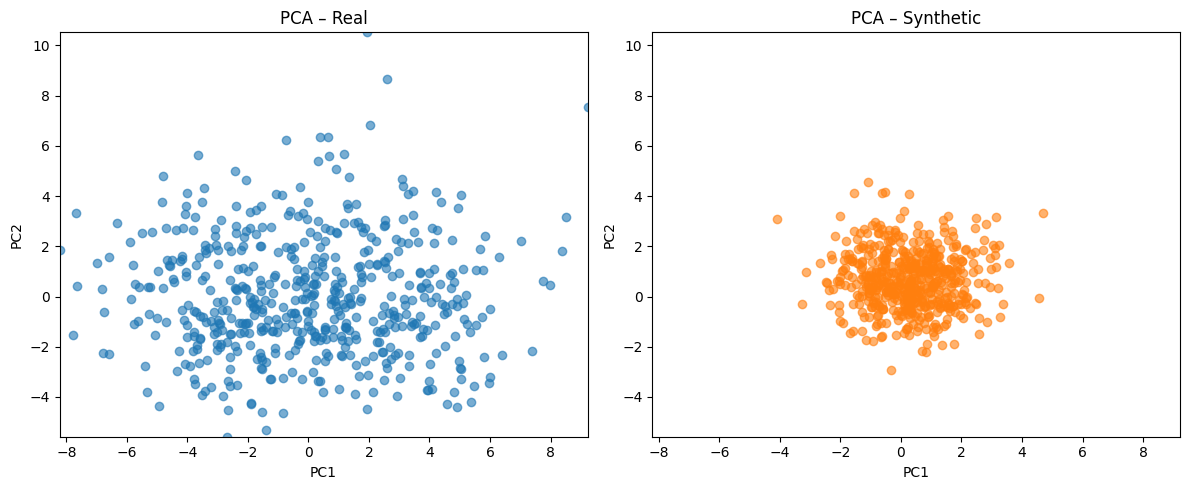

In [35]:
# Extract numerical data and find common columns
df_real_num = df_real.select_dtypes(include='number').dropna(axis=1)
df_syn_num = df_syn.select_dtypes(include='number').dropna(axis=1)

common_cols = list(set(df_real_num.columns) & set(df_syn_num.columns))
df_real_num = df_real_num[common_cols]
df_syn_num = df_syn_num[common_cols]

# PCA: fit on real data, transform both datasets
pca = PCA(n_components=2)
real_pca = pca.fit_transform(df_real_num)
syn_pca = pca.transform(df_syn_num)

# Visualization: side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(real_pca[:, 0], real_pca[:, 1], alpha=0.6, c='tab:blue')
axes[0].set_title("PCA – Real")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(syn_pca[:, 0], syn_pca[:, 1], alpha=0.6, c='tab:orange')
axes[1].set_title("PCA – Synthetic")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

# Use the same axis limits for both plots
x_min = min(real_pca[:, 0].min(), syn_pca[:, 0].min())
x_max = max(real_pca[:, 0].max(), syn_pca[:, 0].max())
y_min = min(real_pca[:, 1].min(), syn_pca[:, 1].min())
y_max = max(real_pca[:, 1].max(), syn_pca[:, 1].max())

for ax in axes:
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()


### t-SNE
uses t-SNE to reduce the dimensionality of real and synthetic datasets to two components and visualizes their structures in side-by-side scatter plots with shared axis scaling for better comparison.

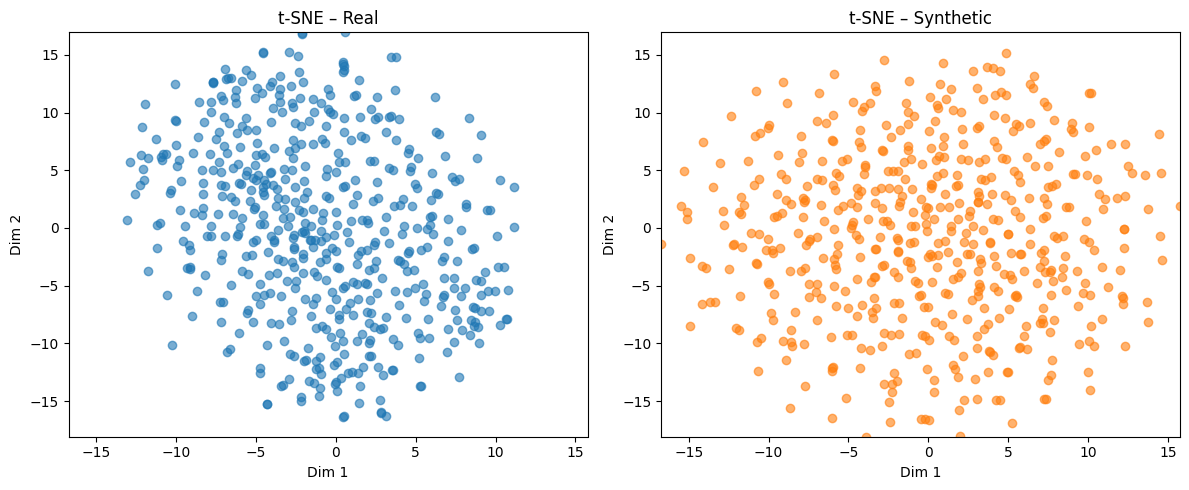

In [36]:
# t-SNE for real and synthetic data
tsne_real = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
real_tsne = tsne_real.fit_transform(df_real_num)

tsne_syn = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
syn_tsne = tsne_syn.fit_transform(df_syn_num)

# Calculate common axis limits
x_min = min(real_tsne[:, 0].min(), syn_tsne[:, 0].min())
x_max = max(real_tsne[:, 0].max(), syn_tsne[:, 0].max())
y_min = min(real_tsne[:, 1].min(), syn_tsne[:, 1].min())
y_max = max(real_tsne[:, 1].max(), syn_tsne[:, 1].max())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(real_tsne[:, 0], real_tsne[:, 1], alpha=0.6, c='tab:blue')
axes[0].set_title("t-SNE – Real")
axes[0].set_xlabel("Dim 1")
axes[0].set_ylabel("Dim 2")
axes[0].set_xlim(x_min, x_max)
axes[0].set_ylim(y_min, y_max)

axes[1].scatter(syn_tsne[:, 0], syn_tsne[:, 1], alpha=0.6, c='tab:orange')
axes[1].set_title("t-SNE – Synthetic")
axes[1].set_xlabel("Dim 1")
axes[1].set_ylabel("Dim 2")
axes[1].set_xlim(x_min, x_max)
axes[1].set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()


### Joint t-SNE
reduces real and synthetic datasets to two dimensions using t-SNE, visualizes both in a shared scatter plot, and highlights the centroid of each dataset to illustrate their structural proximity or separation.

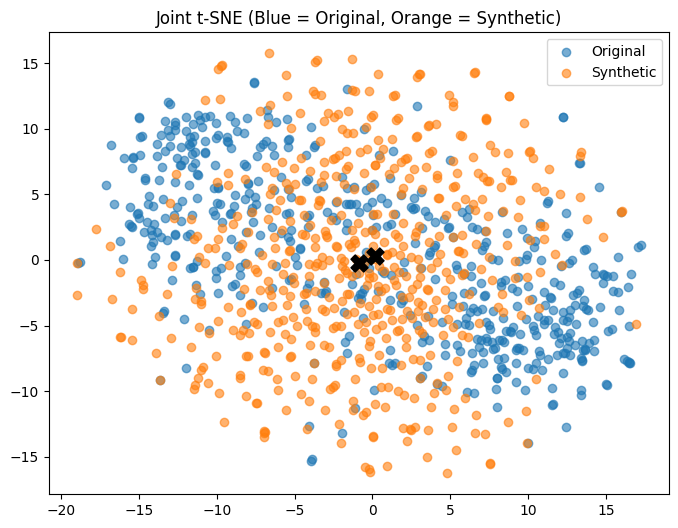

In [37]:
def centroide(original: pd.DataFrame,
              synthetic: pd.DataFrame,
              eps=0.5,
              min_samples=5):

    # Extract numerical & categorical columns
    num_cols = original.select_dtypes(include=[np.number]).columns.intersection(
               synthetic.select_dtypes(include=[np.number]).columns)
    cat_cols = original.select_dtypes(exclude=[np.number]).columns.intersection(
               synthetic.select_dtypes(exclude=[np.number]).columns)

    # One-hot encode categorical features
    if len(cat_cols) > 0:
        combined_cat = pd.concat([original[cat_cols], synthetic[cat_cols]], axis=0)
        encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        encoder.fit(combined_cat)
        orig_cat = encoder.transform(original[cat_cols])
        syn_cat = encoder.transform(synthetic[cat_cols])
    else:
        orig_cat = np.empty((len(original), 0))
        syn_cat = np.empty((len(synthetic), 0))

    # Scale numerical features
    orig_num = original[num_cols].to_numpy()
    syn_num  = synthetic[num_cols].to_numpy()
    scaler = StandardScaler()
    scaler.fit(np.vstack([orig_num, syn_num]))
    orig_num = scaler.transform(orig_num)
    syn_num  = scaler.transform(syn_num)

    # Combine numerical and categorical features
    X_orig = np.hstack([orig_num, orig_cat])
    X_syn  = np.hstack([syn_num,  syn_cat])
    labels_orig = np.zeros(len(X_orig), dtype=int)   # 0 = Original
    labels_syn  = np.ones(len(X_syn),  dtype=int)    # 1 = Synthetic

    X_joint = np.vstack([X_orig, X_syn])
    labels = np.concatenate([labels_orig, labels_syn])

    # Color mapping: 0 -> Blue, 1 -> Orange
    color_map = {0: '#1f77b4', 1: '#ff7f0e'}

    # t-SNE transformation
    tsne_joint = TSNE(n_components=2, random_state=42).fit_transform(X_joint)

    # Compute centroids for each class (Original/Synthetic)
    centroids = []
    for label in np.unique(labels):
        points = tsne_joint[labels == label]
        centroid = points.mean(axis=0)
        centroids.append(centroid)
    centroids = np.array(centroids)

    # Plot
    plt.figure(figsize=(8, 6))
    for label in np.unique(labels):
        idx = labels == label
        plt.scatter(tsne_joint[idx, 0], tsne_joint[idx, 1],
                    c=color_map[label],
                    label="Original" if label == 0 else "Synthetic",
                    alpha=0.6)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                c='black', marker='X', s=150)  # Centroids in black
    plt.title('Joint t-SNE (Blue = Original, Orange = Synthetic)')
    plt.legend()
    plt.show()


# Call function with real and synthetic data
centroide(df_real, df_syn)


### K-Means Clustering
applies K-Means clustering on PCA- and t-SNE-transformed real and synthetic data, visualizes the resulting clusters side-by-side, and calculates Silhouette Scores to evaluate and compare the quality of clustering in both datasets.

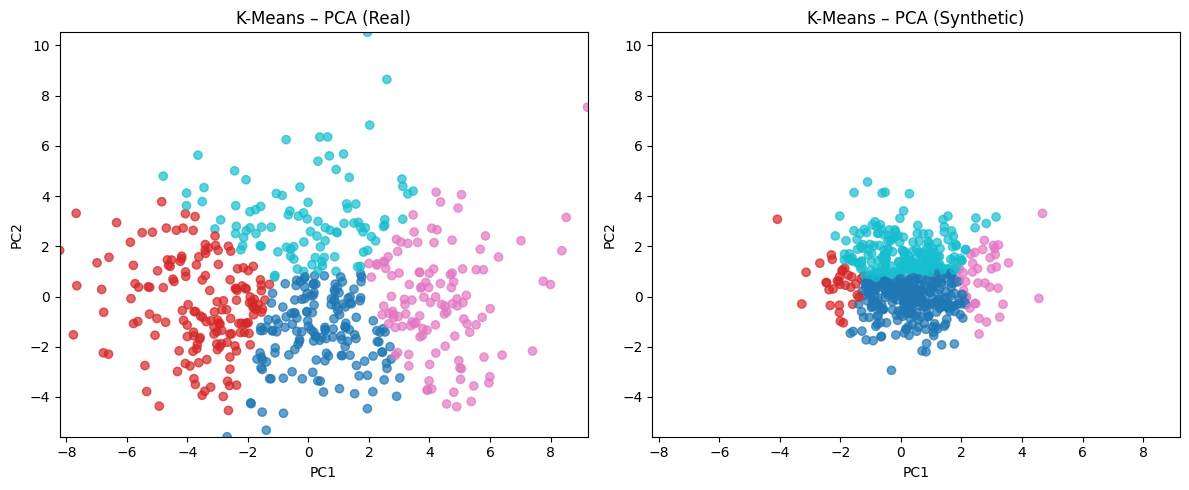

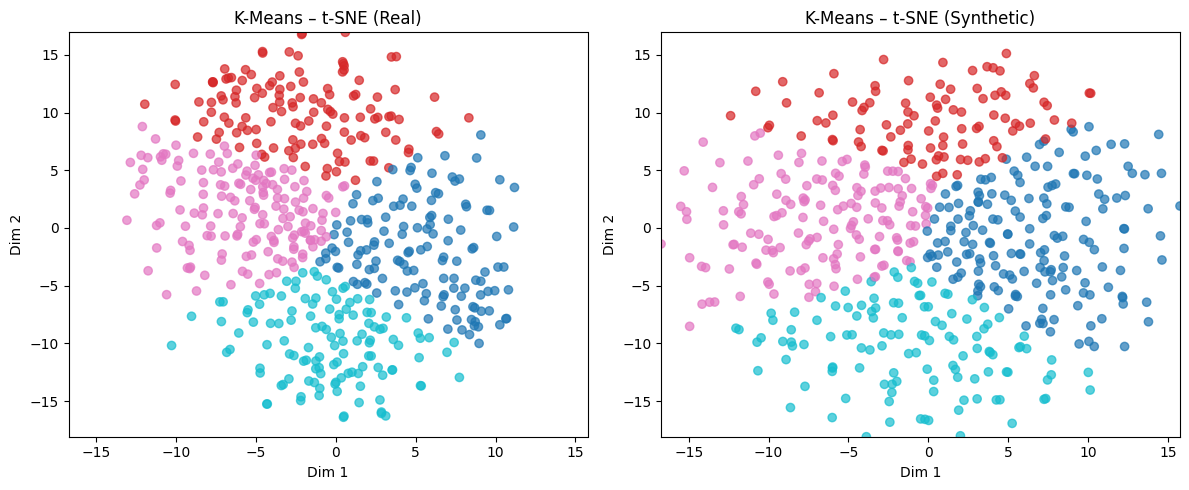

Silhouette Score (PCA – Real):         0.3254785401392916
Silhouette Score (PCA – Synthetic):    0.241655947780497
Silhouette Score (t-SNE – Real):       0.36866793036460876
Silhouette Score (t-SNE – Synthetic):  0.32929378747940063


In [38]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Number of clusters
n_clusters = 4

# --- PCA Clustering ---
kmeans_pca = KMeans(n_clusters=n_clusters, random_state=42)
clusters_real_pca = kmeans_pca.fit_predict(real_pca)
clusters_syn_pca = kmeans_pca.predict(syn_pca)

# Axis limits (PCA)
x_min_pca = min(real_pca[:, 0].min(), syn_pca[:, 0].min())
x_max_pca = max(real_pca[:, 0].max(), syn_pca[:, 0].max())
y_min_pca = min(real_pca[:, 1].min(), syn_pca[:, 1].min())
y_max_pca = max(real_pca[:, 1].max(), syn_pca[:, 1].max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(real_pca[:, 0], real_pca[:, 1], c=clusters_real_pca, cmap='tab10', alpha=0.7)
axes[0].set_title("K-Means – PCA (Real)")
axes[0].set_xlim(x_min_pca, x_max_pca)
axes[0].set_ylim(y_min_pca, y_max_pca)

axes[1].scatter(syn_pca[:, 0], syn_pca[:, 1], c=clusters_syn_pca, cmap='tab10', alpha=0.7)
axes[1].set_title("K-Means – PCA (Synthetic)")
axes[1].set_xlim(x_min_pca, x_max_pca)
axes[1].set_ylim(y_min_pca, y_max_pca)

for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()


# --- t-SNE Clustering ---
kmeans_tsne = KMeans(n_clusters=n_clusters, random_state=42)
clusters_real_tsne = kmeans_tsne.fit_predict(real_tsne)
clusters_syn_tsne = kmeans_tsne.predict(syn_tsne)

x_min_tsne = min(real_tsne[:, 0].min(), syn_tsne[:, 0].min())
x_max_tsne = max(real_tsne[:, 0].max(), syn_tsne[:, 0].max())
y_min_tsne = min(real_tsne[:, 1].min(), syn_tsne[:, 1].min())
y_max_tsne = max(real_tsne[:, 1].max(), syn_tsne[:, 1].max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(real_tsne[:, 0], real_tsne[:, 1], c=clusters_real_tsne, cmap='tab10', alpha=0.7)
axes[0].set_title("K-Means – t-SNE (Real)")
axes[0].set_xlim(x_min_tsne, x_max_tsne)
axes[0].set_ylim(y_min_tsne, y_max_tsne)

axes[1].scatter(syn_tsne[:, 0], syn_tsne[:, 1], c=clusters_syn_tsne, cmap='tab10', alpha=0.7)
axes[1].set_title("K-Means – t-SNE (Synthetic)")
axes[1].set_xlim(x_min_tsne, x_max_tsne)
axes[1].set_ylim(y_min_tsne, y_max_tsne)

for ax in axes:
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")

plt.tight_layout()
plt.show()


# --- Optional: Evaluate clustering quality using Silhouette Score ---
print("Silhouette Score (PCA – Real):        ", silhouette_score(real_pca, clusters_real_pca))
print("Silhouette Score (PCA – Synthetic):   ", silhouette_score(syn_pca, clusters_syn_pca))
print("Silhouette Score (t-SNE – Real):      ", silhouette_score(real_tsne, clusters_real_tsne))
print("Silhouette Score (t-SNE – Synthetic): ", silhouette_score(syn_tsne, clusters_syn_tsne))


### Agglomerative Clustering
reduces real and synthetic datasets into two dimensions using t-SNE, applies agglomerative clustering to the combined data, and visualizes the cluster structure to assess structural consistency between the datasets.

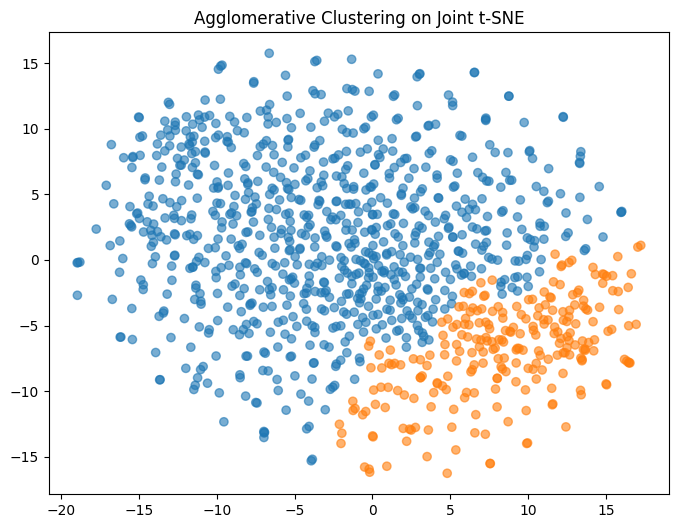

In [39]:
def visualize_structural_consistency(original: pd.DataFrame,
                                     synthetic: pd.DataFrame,
                                     eps=0.5,
                                     min_samples=5):
    # Identify shared numeric and categorical columns
    num_cols = original.select_dtypes(include=[np.number]).columns.intersection(
               synthetic.select_dtypes(include=[np.number]).columns)
    cat_cols = original.select_dtypes(exclude=[np.number]).columns.intersection(
               synthetic.select_dtypes(exclude=[np.number]).columns)

    # One-hot encode categorical features if any
    if len(cat_cols) > 0:
        combined_cat = pd.concat([original[cat_cols], synthetic[cat_cols]], axis=0)
        encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        encoder.fit(combined_cat)
        orig_cat = encoder.transform(original[cat_cols])
        syn_cat = encoder.transform(synthetic[cat_cols])
    else:
        orig_cat = np.empty((len(original), 0))
        syn_cat = np.empty((len(synthetic), 0))

    # Standardize numeric features
    orig_num = original[num_cols].to_numpy()
    syn_num  = synthetic[num_cols].to_numpy()
    scaler = StandardScaler()
    scaler.fit(np.vstack([orig_num, syn_num]))
    orig_num = scaler.transform(orig_num)
    syn_num  = scaler.transform(syn_num)

    # Combine numeric and categorical features
    X_orig = np.hstack([orig_num, orig_cat])
    X_syn  = np.hstack([syn_num,  syn_cat])
    labels_orig = np.zeros(len(X_orig), dtype=int)   # Label 0 = real
    labels_syn  = np.ones(len(X_syn),  dtype=int)     # Label 1 = synthetic

    X_joint = np.vstack([X_orig, X_syn])
    labels = np.concatenate([labels_orig, labels_syn])

    color_map = {0: '#1f77b4', 1: '#ff7f0e'}  # Blue for real, orange for synthetic

    # t-SNE dimensionality reduction
    tsne_joint = TSNE(n_components=2, random_state=42).fit_transform(X_joint)

    # Agglomerative clustering on reduced data
    agg_cluster = AgglomerativeClustering(n_clusters=2).fit(tsne_joint)
    cluster_labels = agg_cluster.labels_

    # Calculate centroids for each cluster
    centroids = []
    for label in np.unique(cluster_labels):
        points = tsne_joint[cluster_labels == label]
        centroid = points.mean(axis=0)
        centroids.append(centroid)
    centroids = np.array(centroids)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.scatter(tsne_joint[:, 0], tsne_joint[:, 1],
                c=[color_map[label] if label in color_map else 'gray' for label in cluster_labels],
                alpha=0.6)
    plt.title("Agglomerative Clustering on Joint t-SNE")
    plt.show()

# Call the function with real and synthetic datasets
visualize_structural_consistency(df_real, df_syn)
